Using device: cpu
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

=== Training ResNet18 (Seed 123) ===
Epoch [1/3] - Loss: 0.4565 - Val Acc: 91.04%
Epoch [2/3] - Loss: 0.1023 - Val Acc: 92.89%
Epoch [3/3] - Loss: 0.0374 - Val Acc: 93.20%

ResNet18 (Seed 123) Test Accuracy: 93.04%
              precision    recall  f1-score   support

       daisy     0.9541    0.9123    0.9327       114
   dandelion     0.9075    0.9752    0.9401       161
        rose     0.9429    0.8684    0.9041       114
   sunflower     1.0000    0.9091    0.9524       121
       tulip     0.8800    0.9635    0.9199       137

    accuracy                         0.9304       647
   macro avg     0.9369    0.9257    0.9298       647
weighted avg     0.9334    0.9304    0.9305       647



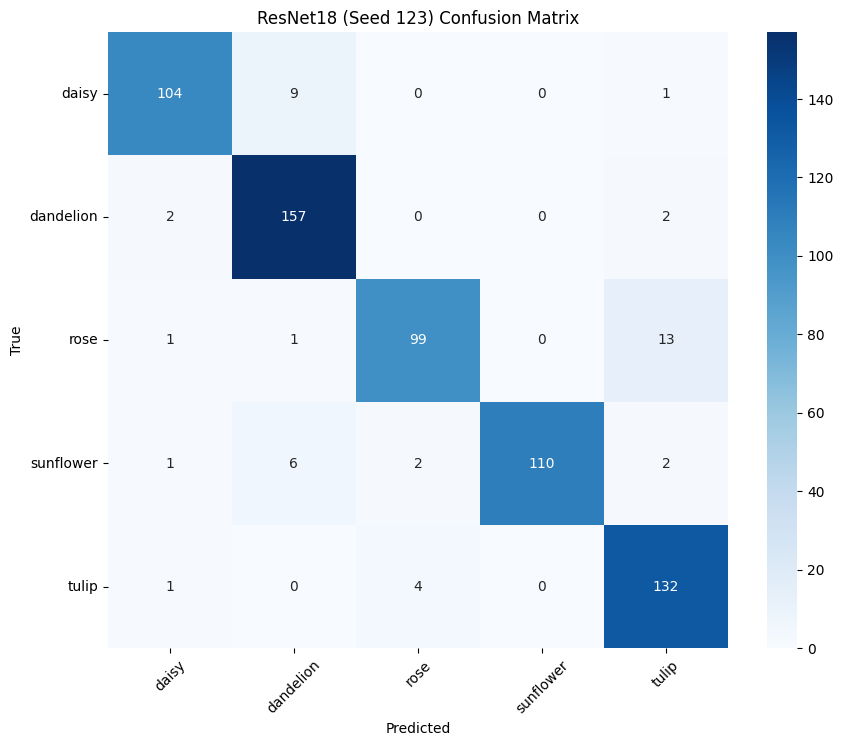


=== Training EfficientNet-B0 (Seed 123) ===
Epoch [1/3] - Loss: 0.8241 - Val Acc: 90.57%
Epoch [2/3] - Loss: 0.2944 - Val Acc: 93.51%
Epoch [3/3] - Loss: 0.1628 - Val Acc: 95.05%

EfficientNet-B0 (Seed 123) Test Accuracy: 92.89%
              precision    recall  f1-score   support

       daisy     0.9444    0.8947    0.9189       114
   dandelion     0.9034    0.9876    0.9436       161
        rose     0.9196    0.9035    0.9115       114
   sunflower     0.9910    0.9091    0.9483       121
       tulip     0.9071    0.9270    0.9170       137

    accuracy                         0.9289       647
   macro avg     0.9331    0.9244    0.9279       647
weighted avg     0.9307    0.9289    0.9288       647



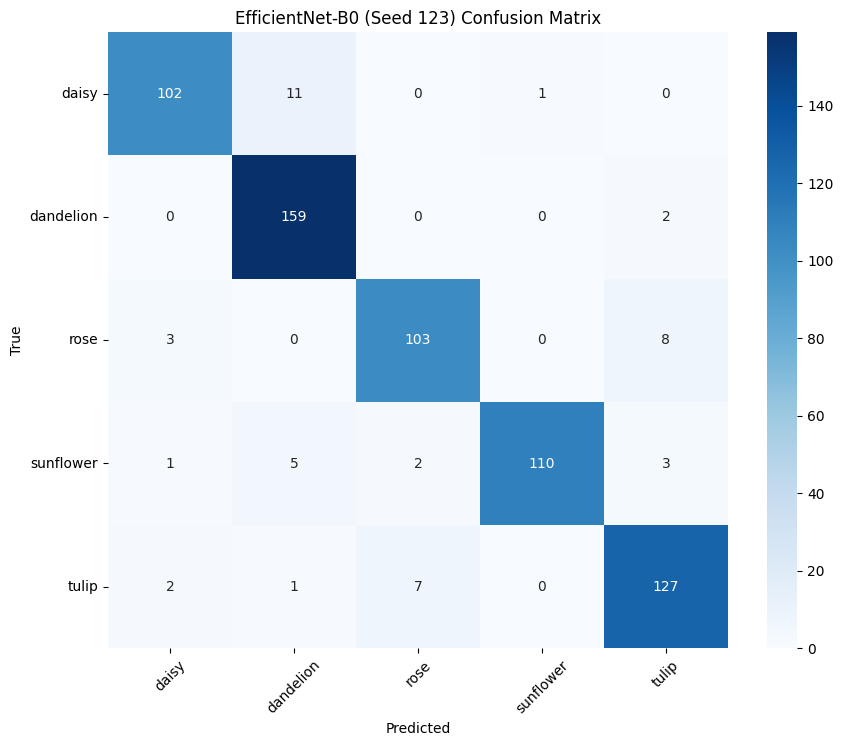


=== Training MobileNetV2 (Seed 123) ===
Epoch [1/3] - Loss: 0.8867 - Val Acc: 90.42%
Epoch [2/3] - Loss: 0.3253 - Val Acc: 92.89%
Epoch [3/3] - Loss: 0.1984 - Val Acc: 93.97%

MobileNetV2 (Seed 123) Test Accuracy: 93.04%
              precision    recall  f1-score   support

       daisy     0.9717    0.9035    0.9364       114
   dandelion     0.9512    0.9689    0.9600       161
        rose     0.8718    0.8947    0.8831       114
   sunflower     0.9658    0.9339    0.9496       121
       tulip     0.8951    0.9343    0.9143       137

    accuracy                         0.9304       647
   macro avg     0.9311    0.9271    0.9287       647
weighted avg     0.9317    0.9304    0.9307       647



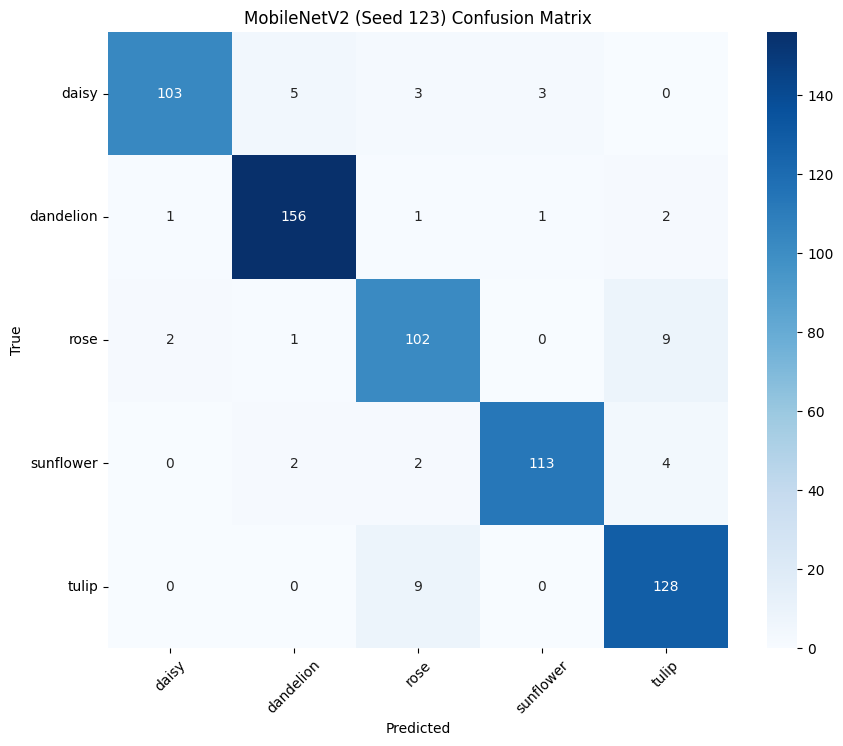


=== Final Results ===
                  Accuracy    
                      mean std
Model                         
EfficientNet-B0  92.890263 NaN
MobileNetV2      93.044822 NaN
ResNet18         93.044822 NaN


In [ ]:
# Flower Classification with ResNet18 
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import seaborn as sns

# ==== CONFIGURATION ====
data_dir = r"D:\ml_lern\dataset"
batch_size = 32
image_size = 224  # Standard size for pretrained models
epochs = 15
learning_rate = 0.0001
model_save_path = "models/flower_resnet18.pth"
seeds = [ 123,]  # For statistical significance

# ==== ENHANCED DATA TRANSFORMS ====
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

# ==== MULTI-MODEL TRAINING FUNCTION ====
def train_and_evaluate(model, train_loader, val_loader, test_loader, criterion, optimizer, epochs, model_name):
    print(f"\n=== Training {model_name} ===")
    train_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                val_outputs = model(val_images)
                _, val_preds = torch.max(val_outputs, 1)
                val_correct += (val_preds == val_labels).sum().item()
                val_total += val_labels.size(0)

        val_acc = 100 * val_correct / val_total
        train_losses.append(running_loss / len(train_loader))
        val_accuracies.append(val_acc)
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {train_losses[-1]:.4f} - Val Acc: {val_acc:.2f}%")

    # Test Evaluation
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for test_images, test_labels in test_loader:
            test_images, test_labels = test_images.to(device), test_labels.to(device)
            test_outputs = model(test_images)
            _, test_preds = torch.max(test_outputs, 1)
            test_correct += (test_preds == test_labels).sum().item()
            test_total += test_labels.size(0)
            all_preds.extend(test_preds.cpu().numpy())
            all_labels.extend(test_labels.cpu().numpy())

    test_acc = 100 * test_correct / test_total
    print(f"\n{model_name} Test Accuracy: {test_acc:.2f}%")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()
    
    return test_acc, train_losses, val_accuracies

# ==== MAIN EXPERIMENT LOOP ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset once
full_dataset = datasets.ImageFolder(root=data_dir)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")

results = []
for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Create splits with correct transforms
    train_set = datasets.ImageFolder(root=data_dir, transform=train_transform)
    test_size = int(0.15 * len(train_set))
    val_size = int(0.15 * len(train_set))
    train_size = len(train_set) - val_size - test_size
    
    train_set, val_set, test_set = random_split(
        train_set, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )
    
    # Apply test transform to val/test
    val_set.dataset.transform = test_transform
    test_set.dataset.transform = test_transform
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size)
    test_loader = DataLoader(test_set, batch_size=batch_size)

    # ==== MODEL COMPARISON ====
    models_dict = {
        'ResNet18': models.resnet18(weights='DEFAULT'),
        'EfficientNet-B0': models.efficientnet_b0(weights='DEFAULT'),
        'MobileNetV2': models.mobilenet_v2(weights='DEFAULT')
    }
    
    for name, model in models_dict.items():
        # Modify final layer
        if 'resnet' in name.lower():
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        else:
            if 'efficientnet' in name.lower():
                model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
            else:
                model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        
        model = model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.CrossEntropyLoss()
        
        acc, _, _ = train_and_evaluate(
            model, train_loader, val_loader, test_loader,
            criterion, optimizer, epochs, f"{name} (Seed {seed})"
        )
        results.append((name, seed, acc))

# ==== STATISTICAL ANALYSIS ====
print("\n=== Final Results ===")
import pandas as pd
df = pd.DataFrame(results, columns=['Model', 'Seed', 'Accuracy'])
print(df.groupby('Model').agg({'Accuracy': ['mean', 'std']}))

# ==== SAVE BEST MODEL ====
best_model = models.resnet18(weights='DEFAULT')
best_model.fc = nn.Linear(best_model.fc.in_features, num_classes)
best_model.load_state_dict(torch.load(model_save_path))
best_model.to(device)
torch.save(best_model.state_dict(), "models/best_flower_model.pth")

Using device: cpu
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

=== Training ResNet18 (Seed 42) ===
Epoch [1/5] - Loss: 0.4458 - Val Acc: 91.04%
Epoch [2/5] - Loss: 0.1085 - Val Acc: 92.58%
Epoch [3/5] - Loss: 0.0451 - Val Acc: 92.27%
Epoch [4/5] - Loss: 0.0179 - Val Acc: 92.74%
Epoch [5/5] - Loss: 0.0135 - Val Acc: 92.74%

ResNet18 (Seed 42) Test Accuracy: 93.04%
              precision    recall  f1-score   support

       daisy     0.9173    0.9606    0.9385       127
   dandelion     0.9484    0.9423    0.9453       156
        rose     0.9266    0.8783    0.9018       115
   sunflower     0.9714    0.9358    0.9533       109
       tulip     0.8966    0.9286    0.9123       140

    accuracy                         0.9304       647
   macro avg     0.9321    0.9291    0.9302       647
weighted avg     0.9311    0.9304    0.9304       647



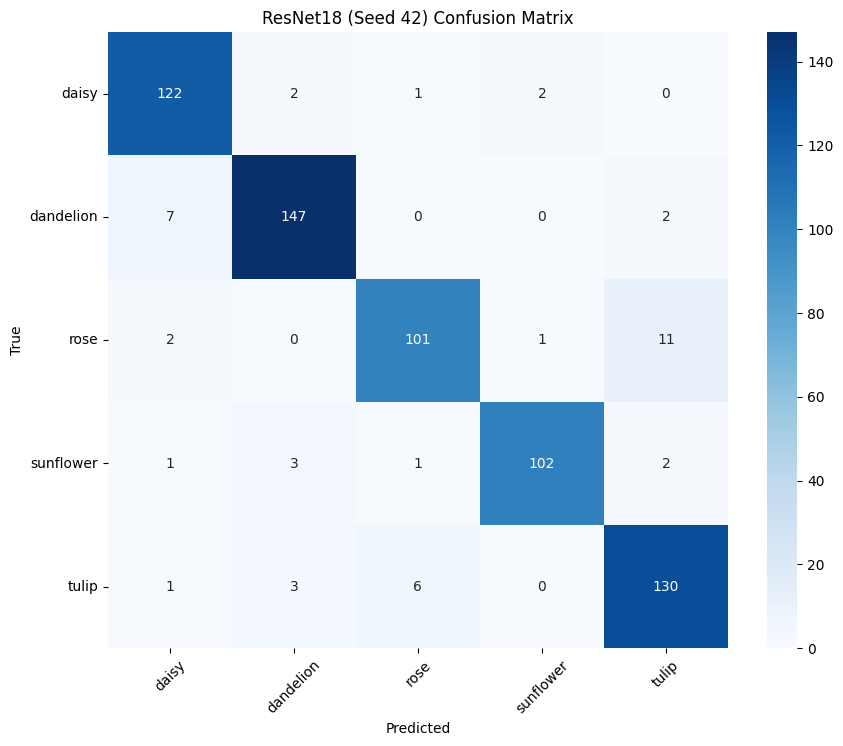


=== Training EfficientNet-B0 (Seed 42) ===
Epoch [1/5] - Loss: 0.8379 - Val Acc: 89.64%
Epoch [2/5] - Loss: 0.2666 - Val Acc: 91.19%
Epoch [3/5] - Loss: 0.1574 - Val Acc: 93.35%
Epoch [4/5] - Loss: 0.1043 - Val Acc: 94.28%
Epoch [5/5] - Loss: 0.0686 - Val Acc: 94.44%

EfficientNet-B0 (Seed 42) Test Accuracy: 93.51%
              precision    recall  f1-score   support

       daisy     0.9444    0.9370    0.9407       127
   dandelion     0.9804    0.9615    0.9709       156
        rose     0.8729    0.8957    0.8841       115
   sunflower     0.9720    0.9541    0.9630       109
       tulip     0.9021    0.9214    0.9117       140

    accuracy                         0.9351       647
   macro avg     0.9344    0.9340    0.9341       647
weighted avg     0.9359    0.9351    0.9354       647



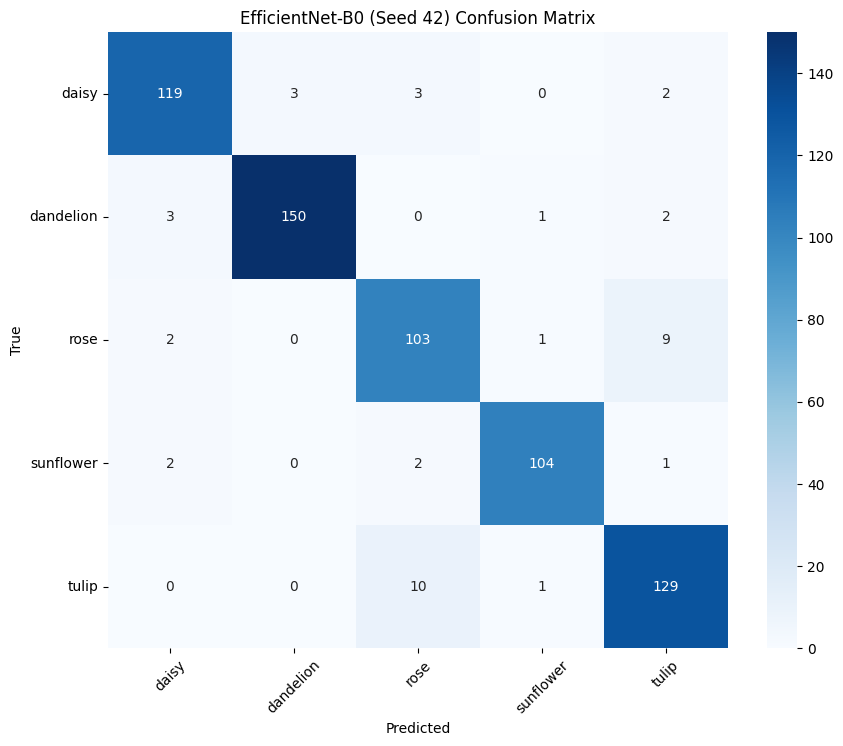


=== Training MobileNetV2 (Seed 42) ===
Epoch [1/5] - Loss: 0.9136 - Val Acc: 89.34%
Epoch [2/5] - Loss: 0.3288 - Val Acc: 90.42%
Epoch [3/5] - Loss: 0.1891 - Val Acc: 91.50%
Epoch [4/5] - Loss: 0.1239 - Val Acc: 92.74%
Epoch [5/5] - Loss: 0.0712 - Val Acc: 93.82%

MobileNetV2 (Seed 42) Test Accuracy: 93.04%
              precision    recall  f1-score   support

       daisy     0.9593    0.9291    0.9440       127
   dandelion     0.9313    0.9551    0.9430       156
        rose     0.8966    0.9043    0.9004       115
   sunflower     0.9352    0.9266    0.9309       109
       tulip     0.9286    0.9286    0.9286       140

    accuracy                         0.9304       647
   macro avg     0.9302    0.9288    0.9294       647
weighted avg     0.9307    0.9304    0.9305       647



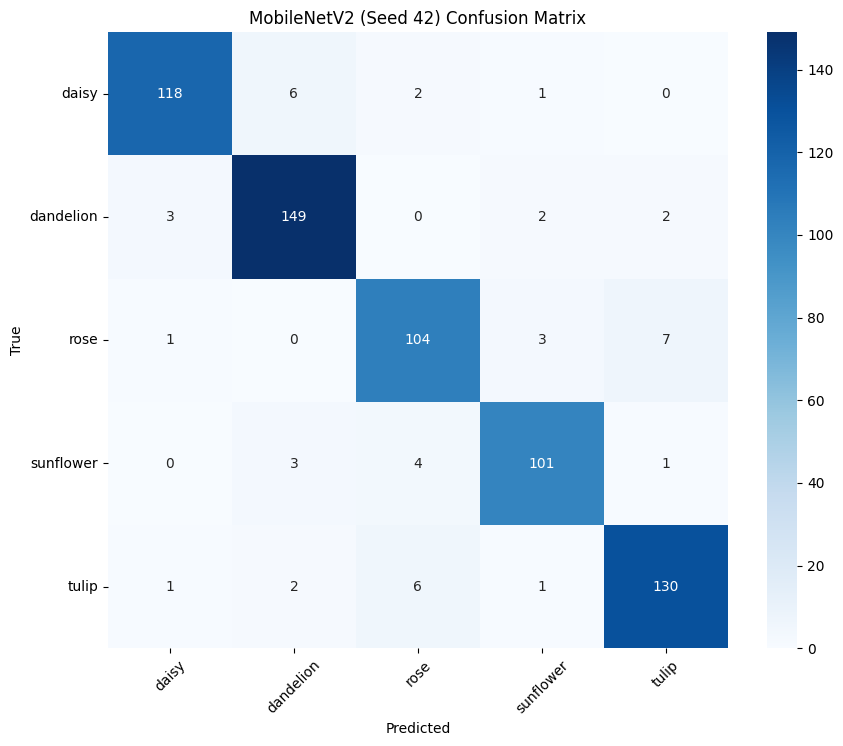


=== Training ResNet18 (Seed 123) ===
Epoch [1/5] - Loss: 0.4565 - Val Acc: 91.04%
Epoch [2/5] - Loss: 0.1023 - Val Acc: 92.89%
Epoch [3/5] - Loss: 0.0374 - Val Acc: 93.20%
Epoch [4/5] - Loss: 0.0313 - Val Acc: 93.66%
Epoch [5/5] - Loss: 0.0196 - Val Acc: 92.74%

ResNet18 (Seed 123) Test Accuracy: 92.43%
              precision    recall  f1-score   support

       daisy     0.9524    0.8772    0.9132       114
   dandelion     0.8785    0.9876    0.9298       161
        rose     0.9099    0.8860    0.8978       114
   sunflower     0.9908    0.8926    0.9391       121
       tulip     0.9220    0.9489    0.9353       137

    accuracy                         0.9243       647
   macro avg     0.9307    0.9184    0.9230       647
weighted avg     0.9273    0.9243    0.9241       647



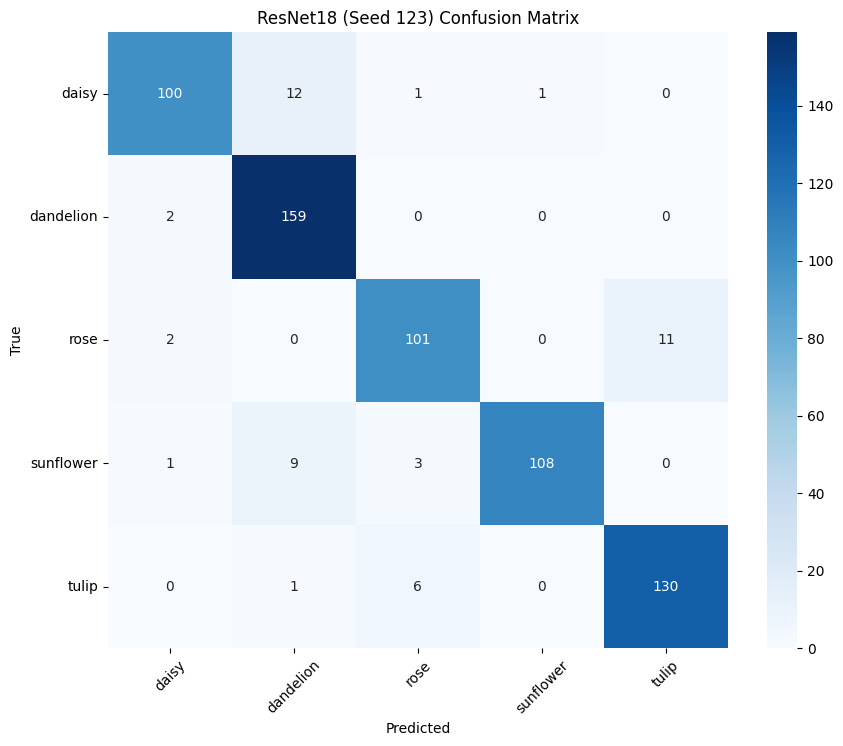


=== Training EfficientNet-B0 (Seed 123) ===
Epoch [1/5] - Loss: 0.8791 - Val Acc: 90.11%
Epoch [2/5] - Loss: 0.2967 - Val Acc: 93.82%
Epoch [3/5] - Loss: 0.1633 - Val Acc: 94.74%
Epoch [4/5] - Loss: 0.0928 - Val Acc: 95.67%
Epoch [5/5] - Loss: 0.0675 - Val Acc: 94.74%

EfficientNet-B0 (Seed 123) Test Accuracy: 93.51%
              precision    recall  f1-score   support

       daisy     0.9811    0.9123    0.9455       114
   dandelion     0.9349    0.9814    0.9576       161
        rose     0.8957    0.9035    0.8996       114
   sunflower     1.0000    0.9091    0.9524       121
       tulip     0.8844    0.9489    0.9155       137

    accuracy                         0.9351       647
   macro avg     0.9392    0.9310    0.9341       647
weighted avg     0.9376    0.9351    0.9353       647



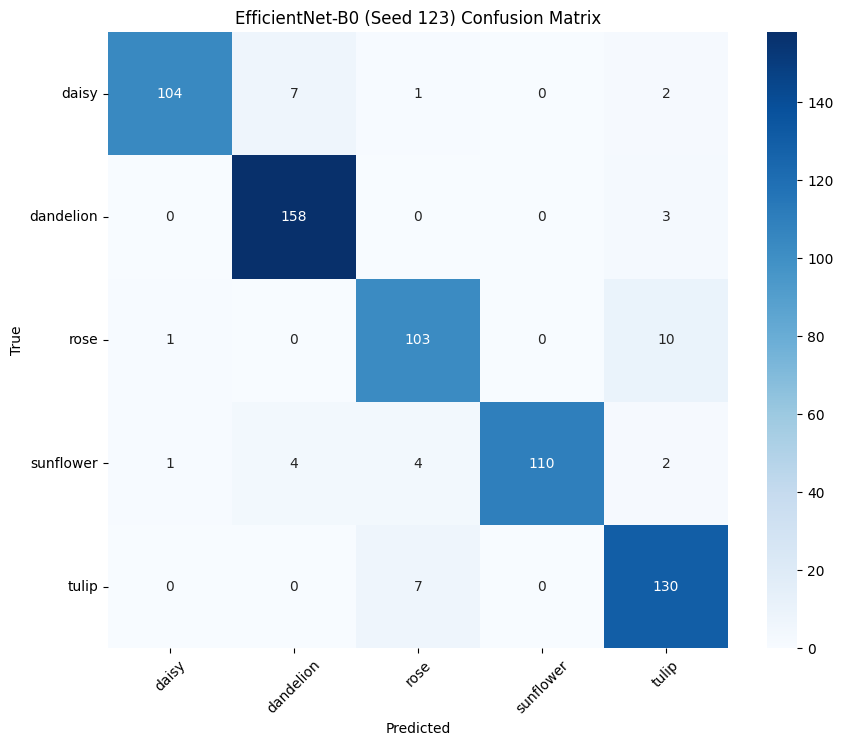


=== Training MobileNetV2 (Seed 123) ===
Epoch [1/5] - Loss: 0.9096 - Val Acc: 89.95%
Epoch [2/5] - Loss: 0.3315 - Val Acc: 91.34%
Epoch [3/5] - Loss: 0.1952 - Val Acc: 93.35%
Epoch [4/5] - Loss: 0.1255 - Val Acc: 93.04%
Epoch [5/5] - Loss: 0.0826 - Val Acc: 94.13%

MobileNetV2 (Seed 123) Test Accuracy: 93.35%
              precision    recall  f1-score   support

       daisy     0.9722    0.9211    0.9459       114
   dandelion     0.9627    0.9627    0.9627       161
        rose     0.8966    0.9123    0.9043       114
   sunflower     0.9655    0.9256    0.9451       121
       tulip     0.8767    0.9343    0.9046       137

    accuracy                         0.9335       647
   macro avg     0.9347    0.9312    0.9326       647
weighted avg     0.9351    0.9335    0.9339       647



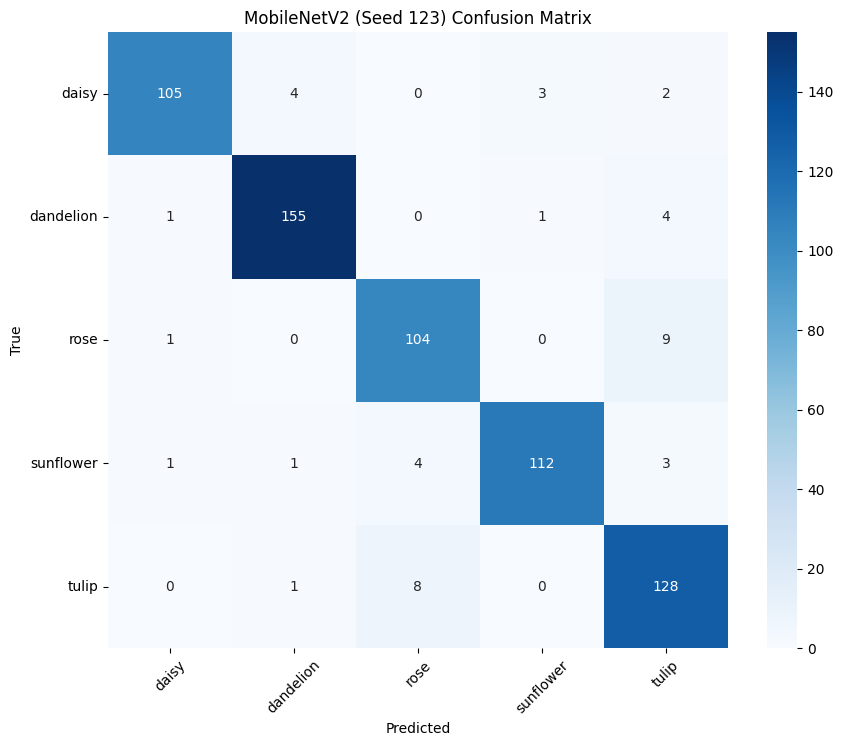


=== Training ResNet18 (Seed 456) ===
Epoch [1/5] - Loss: 0.4314 - Val Acc: 91.04%
Epoch [2/5] - Loss: 0.1055 - Val Acc: 91.65%
Epoch [3/5] - Loss: 0.0525 - Val Acc: 92.74%
Epoch [4/5] - Loss: 0.0187 - Val Acc: 91.65%
Epoch [5/5] - Loss: 0.0114 - Val Acc: 93.04%

ResNet18 (Seed 456) Test Accuracy: 93.51%
              precision    recall  f1-score   support

       daisy     0.9524    0.9259    0.9390       108
   dandelion     0.9766    0.9598    0.9681       174
        rose     0.8519    0.9583    0.9020       120
   sunflower     0.9720    0.9811    0.9765       106
       tulip     0.9225    0.8561    0.8881       139

    accuracy                         0.9351       647
   macro avg     0.9351    0.9363    0.9347       647
weighted avg     0.9370    0.9351    0.9352       647



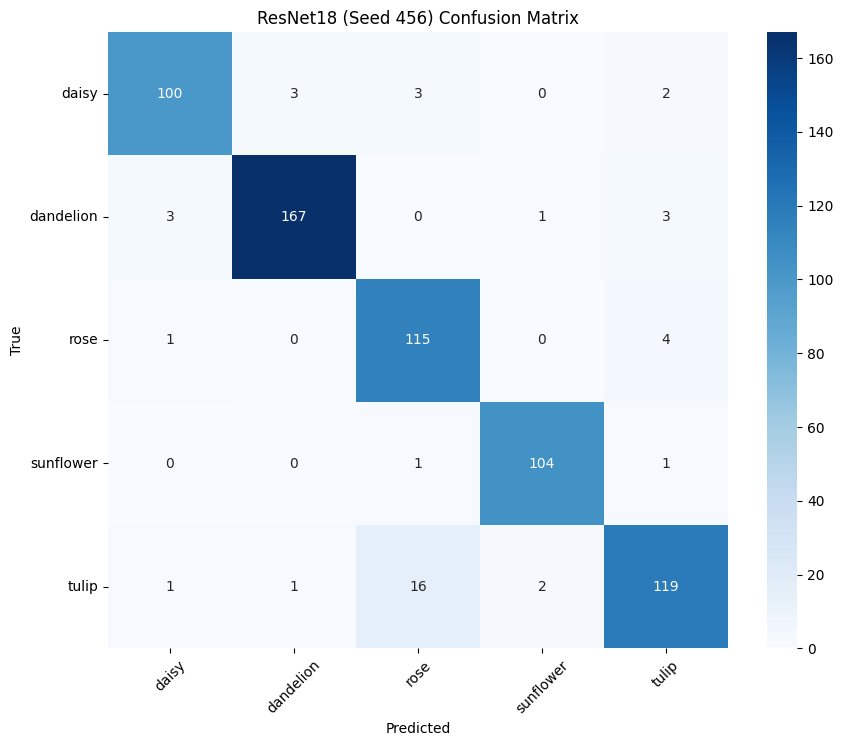


=== Training EfficientNet-B0 (Seed 456) ===
Epoch [1/5] - Loss: 0.8219 - Val Acc: 89.64%
Epoch [2/5] - Loss: 0.2815 - Val Acc: 91.81%
Epoch [3/5] - Loss: 0.1642 - Val Acc: 91.96%
Epoch [4/5] - Loss: 0.0925 - Val Acc: 92.74%
Epoch [5/5] - Loss: 0.0630 - Val Acc: 94.13%

EfficientNet-B0 (Seed 456) Test Accuracy: 93.66%
              precision    recall  f1-score   support

       daisy     0.9703    0.9074    0.9378       108
   dandelion     0.9708    0.9540    0.9623       174
        rose     0.8647    0.9583    0.9091       120
   sunflower     0.9286    0.9811    0.9541       106
       tulip     0.9462    0.8849    0.9145       139

    accuracy                         0.9366       647
   macro avg     0.9361    0.9372    0.9356       647
weighted avg     0.9388    0.9366    0.9367       647



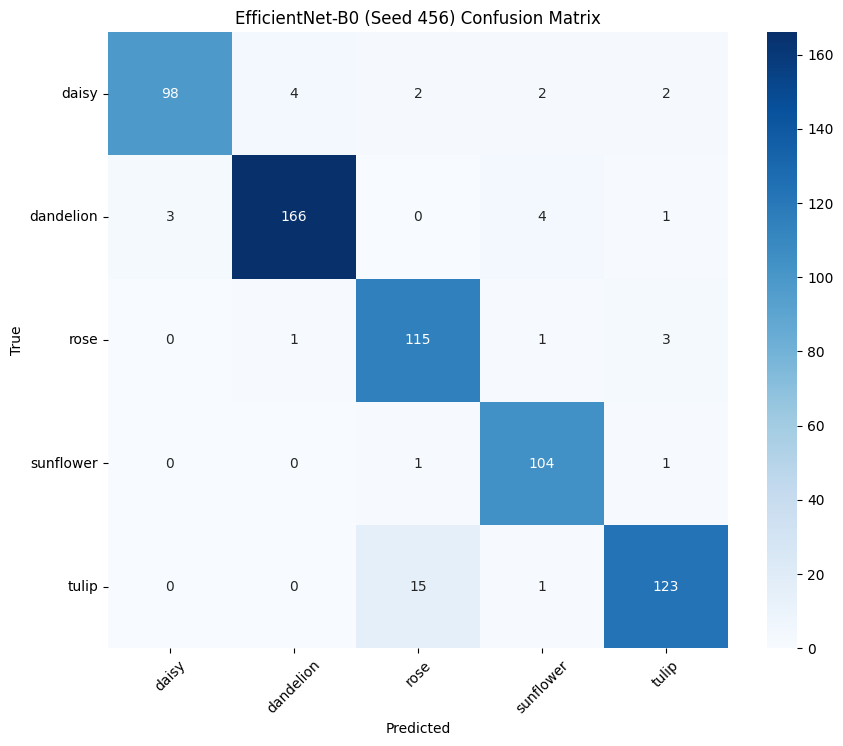


=== Training MobileNetV2 (Seed 456) ===
Epoch [1/5] - Loss: 0.9295 - Val Acc: 89.18%
Epoch [2/5] - Loss: 0.3309 - Val Acc: 91.81%
Epoch [3/5] - Loss: 0.1878 - Val Acc: 91.81%
Epoch [4/5] - Loss: 0.1170 - Val Acc: 92.58%
Epoch [5/5] - Loss: 0.0613 - Val Acc: 92.58%

MobileNetV2 (Seed 456) Test Accuracy: 94.28%
              precision    recall  f1-score   support

       daisy     0.9700    0.8981    0.9327       108
   dandelion     0.9144    0.9828    0.9474       174
        rose     0.9402    0.9167    0.9283       120
   sunflower     0.9904    0.9717    0.9810       106
       tulip     0.9281    0.9281    0.9281       139

    accuracy                         0.9428       647
   macro avg     0.9486    0.9395    0.9435       647
weighted avg     0.9439    0.9428    0.9427       647



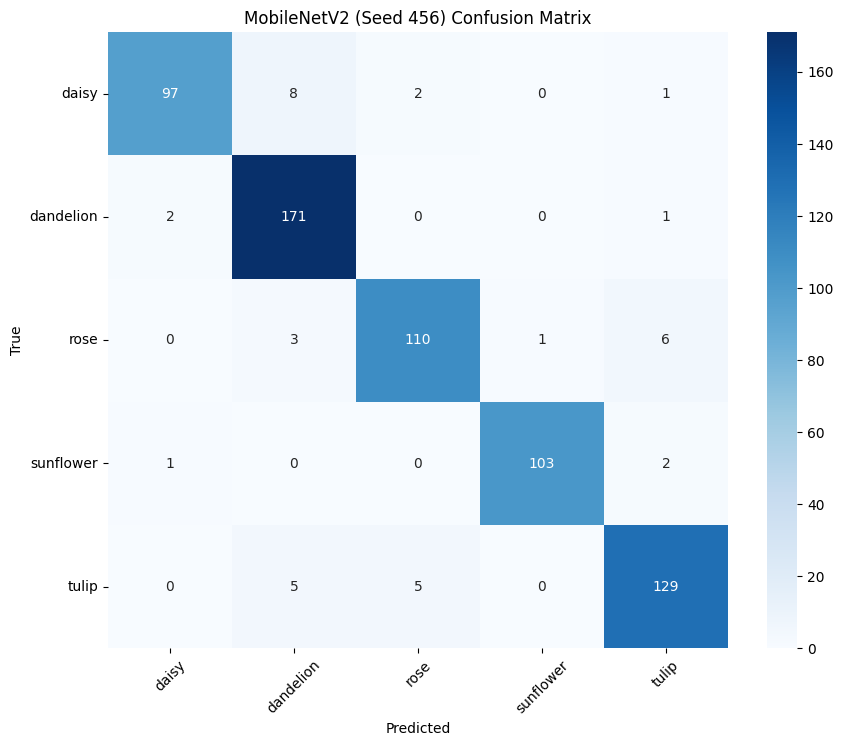


=== Final Results ===
                  Accuracy          
                      mean       std
Model                               
EfficientNet-B0  93.560021  0.089235
MobileNetV2      93.560021  0.643483
ResNet18         92.993302  0.542795


In [4]:
# Flower Classification with ResNet18 
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import seaborn as sns

# ==== CONFIGURATION ====
data_dir = r"D:\ml_lern\dataset"
batch_size = 32
image_size = 224  # Standard size for pretrained models
epochs = 5
learning_rate = 0.0001
model_save_path = "models/flower_resnet18.pth"
seeds = [42, 123, 456]  # For statistical significance

# ==== ENHANCED DATA TRANSFORMS ====
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

# ==== MULTI-MODEL TRAINING FUNCTION ====
def train_and_evaluate(model, train_loader, val_loader, test_loader, criterion, optimizer, epochs, model_name):
    print(f"\n=== Training {model_name} ===")
    train_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                val_outputs = model(val_images)
                _, val_preds = torch.max(val_outputs, 1)
                val_correct += (val_preds == val_labels).sum().item()
                val_total += val_labels.size(0)

        val_acc = 100 * val_correct / val_total
        train_losses.append(running_loss / len(train_loader))
        val_accuracies.append(val_acc)
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {train_losses[-1]:.4f} - Val Acc: {val_acc:.2f}%")

    # Test Evaluation
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for test_images, test_labels in test_loader:
            test_images, test_labels = test_images.to(device), test_labels.to(device)
            test_outputs = model(test_images)
            _, test_preds = torch.max(test_outputs, 1)
            test_correct += (test_preds == test_labels).sum().item()
            test_total += test_labels.size(0)
            all_preds.extend(test_preds.cpu().numpy())
            all_labels.extend(test_labels.cpu().numpy())

    test_acc = 100 * test_correct / test_total
    print(f"\n{model_name} Test Accuracy: {test_acc:.2f}%")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()
    
    return test_acc, train_losses, val_accuracies

# ==== MAIN EXPERIMENT LOOP ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset once
full_dataset = datasets.ImageFolder(root=data_dir)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")

results = []
for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Create splits with correct transforms
    train_set = datasets.ImageFolder(root=data_dir, transform=train_transform)
    test_size = int(0.15 * len(train_set))
    val_size = int(0.15 * len(train_set))
    train_size = len(train_set) - val_size - test_size
    
    train_set, val_set, test_set = random_split(
        train_set, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )
    
    # Apply test transform to val/test
    val_set.dataset.transform = test_transform
    test_set.dataset.transform = test_transform
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size)
    test_loader = DataLoader(test_set, batch_size=batch_size)

    # ==== MODEL COMPARISON ====
    models_dict = {
        'ResNet18': models.resnet18(weights='DEFAULT'),
        'EfficientNet-B0': models.efficientnet_b0(weights='DEFAULT'),
        'MobileNetV2': models.mobilenet_v2(weights='DEFAULT')
    }
    
    for name, model in models_dict.items():
        # Modify final layer
        if 'resnet' in name.lower():
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        else:
            if 'efficientnet' in name.lower():
                model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
            else:
                model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        
        model = model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.CrossEntropyLoss()
        
        acc, _, _ = train_and_evaluate(
            model, train_loader, val_loader, test_loader,
            criterion, optimizer, epochs, f"{name} (Seed {seed})"
        )
        results.append((name, seed, acc))

# ==== STATISTICAL ANALYSIS ====
print("\n=== Final Results ===")
import pandas as pd
df = pd.DataFrame(results, columns=['Model', 'Seed', 'Accuracy'])
print(df.groupby('Model').agg({'Accuracy': ['mean', 'std']}))

# ==== SAVE BEST MODEL ====
best_model = models.resnet18(weights='DEFAULT')
best_model.fc = nn.Linear(best_model.fc.in_features, num_classes)
best_model.load_state_dict(torch.load(model_save_path))
best_model.to(device)
torch.save(best_model.state_dict(), "models/best_flower_model.pth")